# Horn of Africa Rainfall Seasonality

Seasonal cycle of hourly precipitation from ICON and IFS-FESOM
destinE climate projections for 2020 over the Horn of Africa.

**Requires**:
- Polytope auth (see `docs/polytope_setup.md`)
- Conda env `destine` (see `requirements.txt`)

In [1]:
import sys, os
_here = os.getcwd()
if "../get-data" not in sys.path:
    sys.path.insert(0, "../get-data")

import logging, warnings
import earthkit.data
import earthkit.plots
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from polytope_zarr import PolytopeZarrStore

# Silence verbose polytope / earthkit output
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 1. Fetch DestinE data

In [2]:
# ── Configuration ──────────────────────────────────────────────────
MODELS = ["ICON", "IFS-FESOM"]
BBOX = (5, 44, 10, 49)  # (south, west, north, east)

In [3]:
# ── Build lazy store (metadata only — no data fetched yet) ────────
hist_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment="hist",
    levtype="sfc",
    years=range(2000, 2009),
)

scen_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment="SSP3-7.0",
    levtype="sfc",
    years=range(2015, 2050),
)

In [4]:
# ── Open as xarray Datasets (still lazy) ───────────────────────────
ds_hist = hist_store.open()
ds_scen = scen_store.open()

print("Historical store:", ds_hist)
print("Scenario store:", ds_scen)

Historical store: <xarray.Dataset> Size: 6GB
Dimensions:       (model: 2, time: 108, cell: 196608)
Coordinates:
  * model         (model) object 16B 'ICON' 'IFS-FESOM'
  * time          (time) datetime64[ns] 864B 2000-01-01 ... 2008-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 170MB ...
    avg_10v       (model, time, cell) float32 170MB ...
    avg_10ws      (model, time, cell) float32 170MB ...
    avg_2d        (model, time, cell) float32 170MB ...
    avg_2t        (model, time, cell) float32 170MB ...
    avg_ie        (model, time, cell) float32 170MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 170MB ...
    avg_tnlwrfcs  (model, time, cell) float32 170MB ...
    avg_tnswrf    (model, time, cell) float32 170MB ...
    avg_tnswrfcs  (model, time, cell) float32 170MB ...
    avg_tprate    (model, time, cell) float32 170MB ...
    avg_tsrwe     (

In [5]:
# ── Fetch spatially‑subsetted climatologies with batching ──────────
# .polytope.sel() auto‑sets batch_years from the time slice, so each
# call = a single Polytope request per model × period

mean_data_hist = {}  # model -> xr.DataArray
mean_data_scen = {}  # model -> xr.DataArray

for model in MODELS:
    print(f"Fetching {model} ...")

    # Historical: 1990-01 to 1999-12
    hist_field = ds_hist["avg_tprate"].polytope.sel(
        model=model, time=slice("1990-01", "1999-12"), bbox=BBOX
    )
    mean_space_hist = hist_field.mean(dim="points", skipna=True).groupby("time.month").mean() * 86400  # convert from kg m-2 s-1 to mm/day
    mean_data_hist[model] = mean_space_hist

    # Scenario: 2040-01 to 2049-12
    scen_field = ds_scen["avg_tprate"].polytope.sel(
        model=model, time=slice("2040-01", "2049-12"), bbox=BBOX
    )
    mean_space_scen = scen_field.mean(dim="points", skipna=True).groupby("time.month").mean() * 86400  # convert from kg m-2 s-1 to mm/day
    mean_data_scen[model] = mean_space_scen

Fetching ICON ...
  🌍 boundingbox request for avg_tprate (1990/1991/1992/1993/1994/1995/1996/1997/1998/1999-1/2/3/4/5/6/7/8/9/10/11/12)


2026-07-23 14:22:31 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-23 14:22:31 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  points:\n'
            '  - - 10\n'
            '    - 44\n'
            '  - - 5\n'
            '    - 49\n'
            '  type: boundingbox\n'
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ICON\n'
            'month: 1/2/3/4/5/6/7/8/9/10/11/12\n'
            'param: avg_tprate\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clmn\n'
            'type: fc\n'
            'year: 1990/1991/1992/1993/1994/1995/1996/1997/1998/1999\n',
 'verb': 'retrieve'}
2026-07-23 14:22:31 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-23 14:22:31 - INFO - Request accepted. 

01ejwrk982xp10e000ph7qz3pc:   0%|          | 0.00/835k [00:00<?, ?B/s]

  🌍 boundingbox request for avg_tprate (2040/2041/2042/2043/2044/2045/2046/2047/2048/2049-1/2/3/4/5/6/7/8/9/10/11/12)


01ejwrk982xp10p000wpg8bypj:   0%|          | 0.00/840k [00:00<?, ?B/s]

Fetching IFS-FESOM ...
  🌍 boundingbox request for avg_tprate (1990/1991/1992/1993/1994/1995/1996/1997/1998/1999-1/2/3/4/5/6/7/8/9/10/11/12)


01ejwrk982xp1140006j8rcs62:   0%|          | 0.00/837k [00:00<?, ?B/s]

  🌍 boundingbox request for avg_tprate (2040/2041/2042/2043/2044/2045/2046/2047/2048/2049-1/2/3/4/5/6/7/8/9/10/11/12)


01ejwrk982xp11a000psxdzg59:   0%|          | 0.00/836k [00:00<?, ?B/s]

## 2. Plot seasonal cycle changes

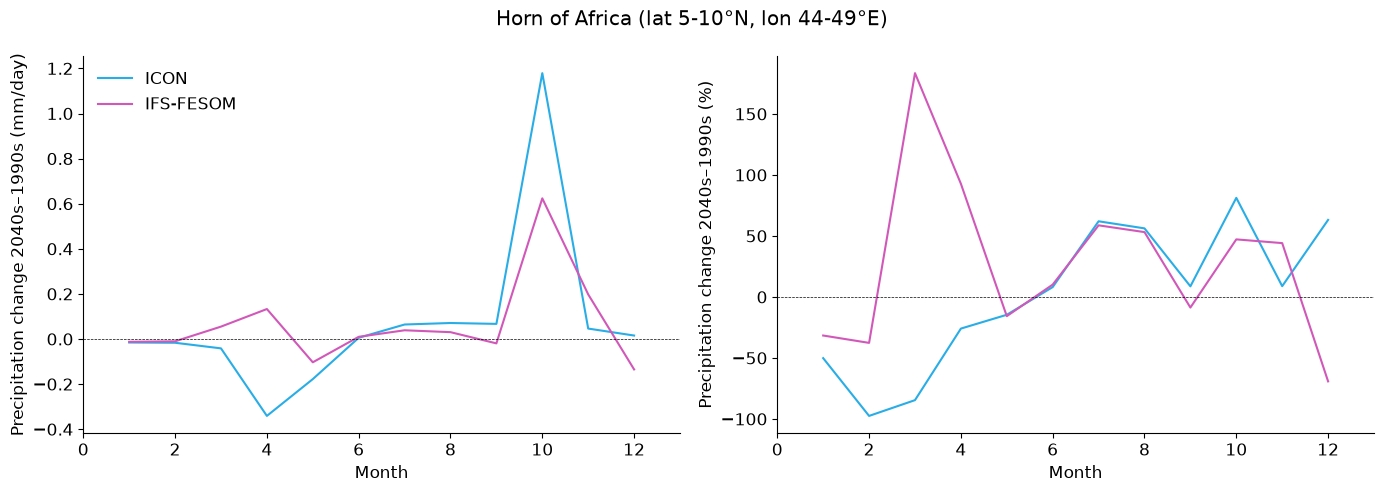

In [8]:
fsize = 12
plt.rcParams["font.size"] = fsize
fig, axs = plt.subplots(1, 2, figsize = (14, 5), layout = "tight")

#absolute change
axs[0].plot(mean_data_scen["ICON"].month, mean_data_scen["ICON"].avg_tprate - mean_data_hist["ICON"].avg_tprate, color="#29ADE6", label="ICON")
axs[0].plot(mean_data_scen["IFS-FESOM"].month, mean_data_scen["IFS-FESOM"].avg_tprate - mean_data_hist["IFS-FESOM"].avg_tprate, color="#D158B9", label="IFS-FESOM")

axs[0].set_xlabel("Month")
axs[0].set_ylabel("Precipitation change 2040s–1990s (mm/day)")
axs[0].hlines(0, 0, 13, color="black", linewidth=0.5, linestyle="--")
axs[0].set_xlim(0, 13)

axs[0].spines["top"].set_visible(False)
axs[0].spines["right"].set_visible(False)

axs[0].legend(edgecolor="white")

#relative change
axs[1].plot(mean_data_scen["ICON"].month, (mean_data_scen["ICON"].avg_tprate - mean_data_hist["ICON"].avg_tprate) / mean_data_hist["ICON"].avg_tprate * 100, color="#29ADE6", label="ICON")
axs[1].plot(mean_data_scen["IFS-FESOM"].month, (mean_data_scen["IFS-FESOM"].avg_tprate - mean_data_hist["IFS-FESOM"].avg_tprate) / mean_data_hist["IFS-FESOM"].avg_tprate * 100, color="#D158B9", label="IFS-FESOM")

axs[1].set_xlabel("Month")
axs[1].set_ylabel("Precipitation change 2040s–1990s (%)")
axs[1].hlines(0, 0, 13, color="black", linewidth=0.5, linestyle="--")
axs[1].set_xlim(0, 13)

axs[1].spines["top"].set_visible(False)
axs[1].spines["right"].set_visible(False)


plt.suptitle("Horn of Africa (lat 5-10°N, lon 44-49°E)")
plt.savefig("plots/seasonality_hornofafrica_monthly_change.png", dpi=300)